## Elliptic integrals

First, let's write some plot functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import (ellipk, # ellipk = complete 1kd
                           ellipkinc, # ellipkinc = incomplete 1kd
                           ellipe, # ellipe = complete 2kd
                           ellipeinc) # ellipeinc = incomplete 2kd

In [2]:
# Global staff
phi_array = np.linspace(0, 2 * np.pi, 150) # Long array of phi in [0, 2 * pi]
some_values = np.linspace(0, 1, 10, endpoint = False) # k or e, some value in [0, 1)
values_array = np.linspace(0, 1, 150, endpoint = False) # k or e, many values in [0, 1)

In [3]:
# Plot the integrand function
def integrand_plot(kind):
    global integrand, some_values, phi_array

    plt.figure(figsize = (8, 6))
    plt.title('Integrand Function vs Angle')
    plt.xlabel(r'$\phi$')
    positions = np.linspace(0, 2 * np.pi, 9)
    labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$']
    plt.xticks(positions, labels)

    if kind == 1:
        for i, values in enumerate(some_values):
            plt.plot(phi_array, integrand[:, i], label = fr'$k = {values:.1f}$')
        plt.ylabel(r'$\frac{d}{d \phi}\,K(\phi; k)$')

    if kind == 2:
        for i, values in enumerate(some_values):
            plt.plot(phi_array, integrand[:, i], label = fr'$e = {values:.1f}$')
        plt.ylabel(r'$\frac{d}{d \phi}\,E(\phi; e)$')

    plt.legend(bbox_to_anchor = (1, 1))
    plt.show()

    return None

In [4]:
# Plot the complete elliptic integral of first or second kind vs k or e
def plot_kind(kind):
    global values_array, complete_first_kind, complete_second_kind
    if kind == 1:
        plt.title('Complete First Kind Integral vs Modulus')
        plt.plot(values_array, complete_first_kind, color = 'red', label = r'$\int_0^{\pi/2} \frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}$')
        plt.xlabel(r'$k$')
        plt.ylabel('$K_c(k)$')

    if kind == 2:
        plt.title('Complete Second Kind Integral vs Eccentricity')
        plt.plot(values_array, complete_second_kind, color = 'red', label = r'$\int_0^{\frac{\pi}{2}}\sqrt{1 - e^2\sin^2\phi}\;d\phi$')
        plt.xlabel(r'$e$')
        plt.ylabel('$E_c(e)$')

    plt.legend(loc = 'best')
    plt.show()

    return None

In [5]:
# Plot the derivative with respect k or e of complete elliptic integral of first or second kind, against k or e
def plot_grad(kind):
    global values_array, grad

    if kind == 1:
        plt.title('Derivative of Complete First Kind Integral vs Modulus')
        plt.plot(values_array, grad, color = 'orange', label = r'$\frac{d}{dk}\,\int_0^{\pi/2} \frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}$')
        plt.xlabel(r'$k$')
        plt.ylabel(r'$\frac{d}{dk}\,K_c(k)$')

    if kind == 2:
        plt.title('Derivative of Complete Second Kind Integral vs Eccentricity')
        plt.plot(values_array, grad, color = 'orange', label = r'$\frac{d}{de}\,\int_0^{\frac{\pi}{2}}\sqrt{1 - e^2\sin^2\phi}\;d\phi$')
        plt.xlabel(r'$e$')
        plt.ylabel(r'$\frac{d}{de}\,E_c(e)$')

    plt.legend(loc = 'best')
    plt.show()

    return None

In [6]:
# Plot the incomplete elliptic integral of first or second kind vs phi
def plot_phi(kind):

    global some_values, phi_array, incomplete_first_kind, incomplete_second_kind

    plt.figure(figsize = (8, 6))
    plt.xlabel(r'$\phi$')
    positions = np.linspace(0, 2 * np.pi, 9)
    labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$']
    plt.xticks(positions, labels)

    if kind == 1:
        plt.title('Incomplete First Kind Integral vs Angle')
        for i, value in enumerate(some_values):
            plt.plot(phi_array, incomplete_first_kind[:, i], label = fr'$k = {value:.1f}$')
        plt.ylabel(r'$K(\phi; k)$')

    if kind == 2:
        plt.title('Incomplete Second Kind Integral vs Angle')
        for i, value in enumerate(some_values):
            plt.plot(phi_array, incomplete_second_kind[:, i], label = fr'$e = {value:.1f}$')
        plt.ylabel(r'$E(\phi; e)$')

    plt.legend(loc = 'best')
    plt.show()

    return None

In [7]:
# Plot the derivative with respect k or e of incomplete elliptic integral of first or second kind vs phi
def plot_grad_phi(kind):

    global some_values, phi_array, grad

    plt.figure(figsize = (8, 6))
    plt.xlabel(r'$\phi$')
    positions = np.linspace(0, 2 * np.pi, 9)
    labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$']
    plt.xticks(positions, labels)

    if kind == 1:
        plt.title('Derivative of Incomplete First Kind Integral vs Angle')
        for i, eps in enumerate(some_values):
            plt.plot(phi_array, grad[:, i], label = fr'$k = {eps:.1f}$')
        plt.ylabel(r'$\frac{d}{dk}\,K(\phi; k)$')

    if kind == 2:
        plt.title('Derivative of Incomplete Second Kind Integral vs Angle')
        for i, eps in enumerate(some_values):
            plt.plot(phi_array, grad[:, i], label = fr'$e = {eps:.1f}$')
        plt.ylabel(r'$\frac{d}{de}\,E(\phi; e)$')

    plt.legend(loc = 'best')
    plt.show()

    return None

### Elliptic integrals of the first kind

Consider a pendulum of length $L$, released from rest at a maximum angular displacement $\theta_0$ (with $0 < \theta_0 < \pi$).
The equation of motion gives the time $t$ to swing from $\theta = 0$ to $\theta = \theta_0$:

$$
    t = \sqrt{\frac{L}{2g}} \int_0^{\theta_0} \frac{d\theta}{\sqrt{\cos\theta - \cos\theta_0}}
$$

Using the identity:

$$
    \cos\theta - \cos\theta_0 = 2\left(\sin^2\frac{\theta_0}{2} - \sin^2\frac{\theta}{2}\right)
$$

We set:

$$
    k = \sin\frac{\theta_0}{2} \qquad (0 < k < 1)
$$

Introduce a new variable $\phi$ defined by:

$$
    \sin\frac{\theta}{2} = k \sin\phi \quad\Longrightarrow\quad d\theta = \frac{2k\cos\phi}{\sqrt{1 - k^2\sin^2\phi}}\, d\phi
$$

When $\theta$ goes from $0$ to $\theta_0$, $\phi$ goes from $0$ to $\pi/2$. Substituting, the time becomes:

$$
    t = \sqrt{\frac{L}{g}} \int_0^{\pi/2} \frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}
$$

The integral:

$$
    K(\phi;\, k) = \int_0^{\phi} \frac{d\phi'}{\sqrt{1 - k^2\sin^2\phi'}}
$$

Is the incomplete elliptic integral of the first kind, where $\phi$ is called the "amplitude" and $k$ the "modulus".

The integral:

$$
    K(\phi = \frac{\pi}{2};\,k) = \int_0^{\pi/2} \frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}
$$

Is the complete elliptic integral of the first kind.

Let's visualize the integrand function for different values of $k$

In [8]:
integrand = 1 / (np.sqrt(1 - (some_values[None, :] * np.sin(phi_array[:, None])) ** 2)) # Broadcasting trick
integrand

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 1.00000889, 1.00003555, ..., 1.00043569, 1.00056918,
        1.00072053],
       [1.        , 1.00003548, 1.00014195, ..., 1.00174308, 1.0022785 ,
        1.00288635],
       ...,
       [1.        , 1.00003548, 1.00014195, ..., 1.00174308, 1.0022785 ,
        1.00288635],
       [1.        , 1.00000889, 1.00003555, ..., 1.00043569, 1.00056918,
        1.00072053],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(150, 10))

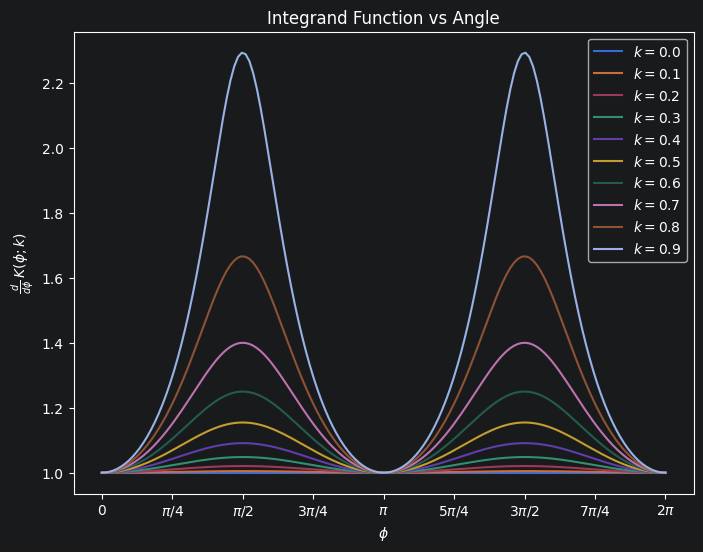

In [9]:
integrand_plot(1)

Let's compute the complete elliptic integral of the first kind in function of modulus $k$

In [10]:
complete_first_kind = ellipk(values_array ** 2)
complete_first_kind

array([1.57079633, 1.57081378, 1.57086615, 1.57095344, 1.57107569,
       1.57123293, 1.57142521, 1.57165259, 1.57191513, 1.57221291,
       1.57254603, 1.57291459, 1.57331869, 1.57375846, 1.57423404,
       1.57474556, 1.57529319, 1.5758771 , 1.57649746, 1.57715447,
       1.57784833, 1.57857926, 1.57934749, 1.58015325, 1.58099681,
       1.58187844, 1.5827984 , 1.58375701, 1.58475457, 1.5857914 ,
       1.58686785, 1.58798426, 1.58914101, 1.59033848, 1.59157708,
       1.59285722, 1.59417934, 1.59554389, 1.59695134, 1.5984022 ,
       1.59989695, 1.60143615, 1.60302033, 1.60465007, 1.60632596,
       1.60804862, 1.60981869, 1.61163683, 1.61350374, 1.61542013,
       1.61738674, 1.61940434, 1.62147373, 1.62359574, 1.62577124,
       1.62800111, 1.63028629, 1.63262773, 1.63502645, 1.63748346,
       1.63999987, 1.64257677, 1.64521534, 1.64791679, 1.65068236,
       1.65351338, 1.65641118, 1.6593772 , 1.66241289, 1.66551978,
       1.66869947, 1.67195361, 1.67528393, 1.67869223, 1.68218

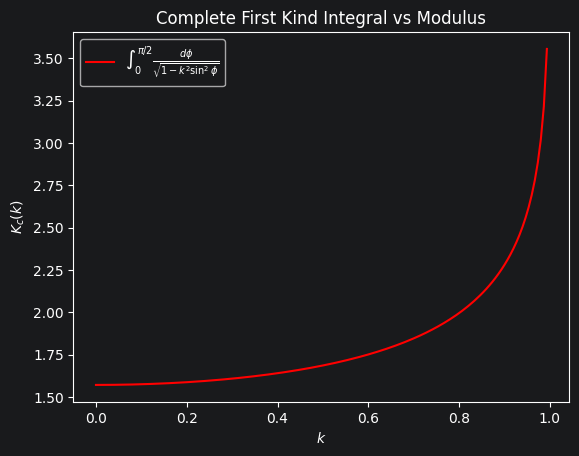

In [11]:
# Plotting
plot_kind(1)

In [12]:
grad = np.gradient(complete_first_kind)
grad

array([1.74537289e-05, 3.49100761e-05, 6.98306283e-05, 1.04772142e-04,
       1.39745123e-04, 1.74760105e-04, 2.09827662e-04, 2.44958415e-04,
       2.80163046e-04, 3.15452306e-04, 3.50837023e-04, 3.86328116e-04,
       4.21936605e-04, 4.57673619e-04, 4.93550410e-04, 5.29578364e-04,
       5.65769009e-04, 6.02134033e-04, 6.38685288e-04, 6.75434810e-04,
       7.12394829e-04, 7.49577778e-04, 7.86996315e-04, 8.24663329e-04,
       8.62591960e-04, 9.00795611e-04, 9.39287965e-04, 9.78083003e-04,
       1.01719501e-03, 1.05663862e-03, 1.09642880e-03, 1.13658089e-03,
       1.17711061e-03, 1.21803410e-03, 1.25936792e-03, 1.30112911e-03,
       1.34333515e-03, 1.38600403e-03, 1.42915430e-03, 1.47280504e-03,
       1.51697590e-03, 1.56168719e-03, 1.60695982e-03, 1.65281542e-03,
       1.69927632e-03, 1.74636560e-03, 1.79410715e-03, 1.84252568e-03,
       1.89164680e-03, 1.94149703e-03, 1.99210388e-03, 2.04349589e-03,
       2.09570267e-03, 2.14875501e-03, 2.20268487e-03, 2.25752552e-03,
      

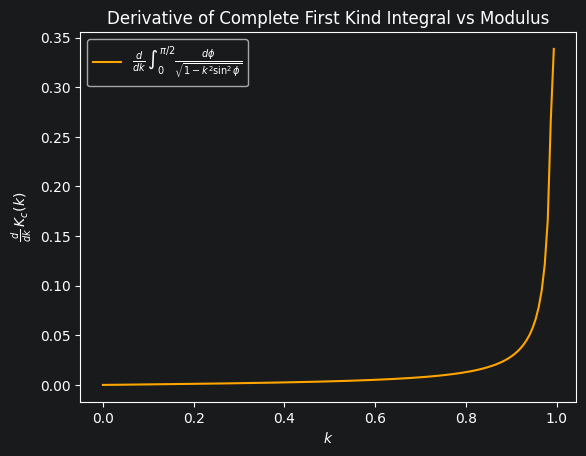

In [13]:
plot_grad(1)

Let's compute the incomplete elliptic integral of the first kind in function of $\phi$, for different values of modulus $k$

In [14]:
incomplete_first_kind = ellipkinc(phi_array[:, None], some_values[None, :] ** 2) # Broadcast trick
incomplete_first_kind

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04216903, 0.04216915, 0.04216953, ..., 0.04217515, 0.04217703,
        0.04217915],
       [0.08433806, 0.08433906, 0.08434205, ..., 0.08438706, 0.08440209,
        0.08441914],
       ...,
       [6.19884725, 6.21464319, 6.26312934, ..., 7.29838894, 7.89680902,
        9.03777742],
       [6.24101628, 6.25681309, 6.30530186, ..., 7.34060084, 7.93903408,
        9.0800174 ],
       [6.28318531, 6.29898225, 6.34747139, ..., 7.38277599, 7.98121111,
        9.12219655]], shape=(150, 10))

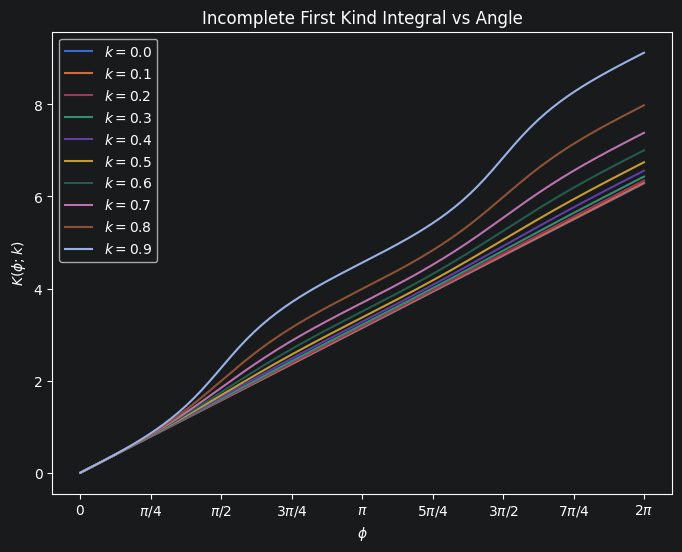

In [15]:
plot_phi(1)

In [16]:
grad = np.gradient(incomplete_first_kind, some_values, axis = 1)
grad

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.24933402e-06, 2.49872800e-06, 4.99769585e-06, ...,
        1.75045369e-05, 2.00099902e-05, 2.12631678e-05],
       [9.98425283e-06, 1.99704197e-05, 3.99484980e-05, ...,
        1.40223046e-04, 1.60409136e-04, 1.70516707e-04],
       ...,
       [1.57959405e-01, 3.21410443e-01, 6.66021220e-01, ...,
        4.89083927e+00, 8.69694239e+00, 1.14096839e+01],
       [1.57968140e-01, 3.21427914e-01, 6.66056171e-01, ...,
        4.89096199e+00, 8.69708279e+00, 1.14098332e+01],
       [1.57969389e-01, 3.21430413e-01, 6.66061168e-01, ...,
        4.89097949e+00, 8.69710280e+00, 1.14098544e+01]], shape=(150, 10))

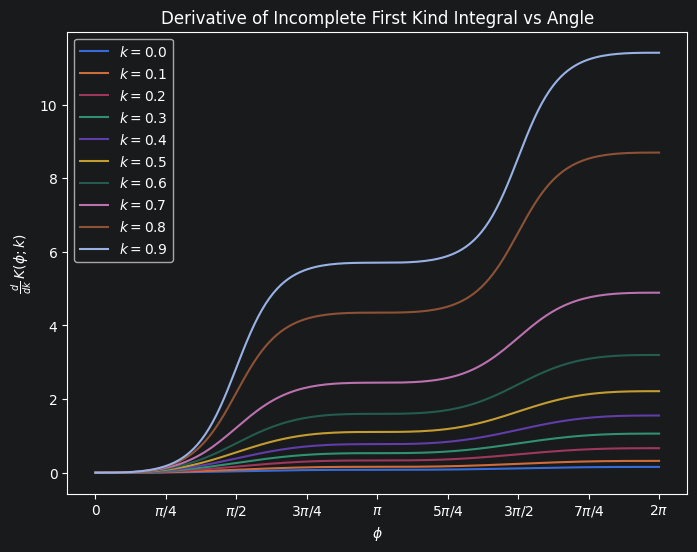

In [17]:
plot_grad_phi(1)

---

### Elliptic integrals of the second kind

Consider an ellipse centered at the origin with semi‑axes $a$ and $b$ described by:

$$
    \frac{x^2}{a^2} + \frac{y^2}{b^2} = 1
$$

We parametrise the ellipse by an angle $\theta$:

$$
    x = a\cos\theta,\qquad y = b\sin\theta,\qquad 0\le\theta\le 2\pi
$$

The infinitesimal arc length differential $ds$ is

$$
    ds = \sqrt{dx^2+dy^2} = \sqrt{a^2\sin^2\theta + b^2\cos^2\theta}\;d\theta
$$

Assume $a > b$. Introducing the eccentricity $e$:

$$
    e = \sqrt{1 - \frac{b ^ 2}{a ^ 2}} \qquad 0 < e < 1
$$

We can write $ds$ using $e$:

$$
    ds = a\sqrt{1 - e^2\cos^2\theta}\;d\theta
$$

To introduce the elliptic integral of the second kind, let's introduce the new angle $\phi$, that is measured with respect the y-axis:

$$
    \phi = \frac{\pi}{2} - \theta
$$

So we can write:

$$
    ds = a\sqrt{1 - e^2\sin^2\phi}\;d\phi
$$

The arc length $s$ from $\phi_a$ to $\phi_b$ is:

$$
    s = a\int_{\phi_a}^{\phi_b}\sqrt{1 - e^2\sin^2\phi}\;d\phi
$$

The integral:

$$
    E(\phi,\, e) = \int_0^{\phi}\sqrt{1 - e^2\sin^2\phi'}\;d\phi'
$$

Is the incomplete elliptic integral of the second kind.

The integral:

$$
    E(\phi = \frac{\pi}{2},\, e) = \int_0^{\frac{\pi}{2}}\sqrt{1 - e^2\sin^2\phi}\;d\phi
$$

Is the complete elliptic integral of the second kind.

Let's visualize the integrand function for different values of eccentricity $e$

In [18]:
integrand = np.sqrt(1 - (some_values[None, :] * np.sin(phi_array[:, None])) ** 2) # Broadcasting trick
integrand

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.99999111, 0.99996446, ..., 0.9995645 , 0.99943114,
        0.99927999],
       [1.        , 0.99996452, 0.99985807, ..., 0.99825995, 0.99772668,
        0.99712195],
       ...,
       [1.        , 0.99996452, 0.99985807, ..., 0.99825995, 0.99772668,
        0.99712195],
       [1.        , 0.99999111, 0.99996446, ..., 0.9995645 , 0.99943114,
        0.99927999],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(150, 10))

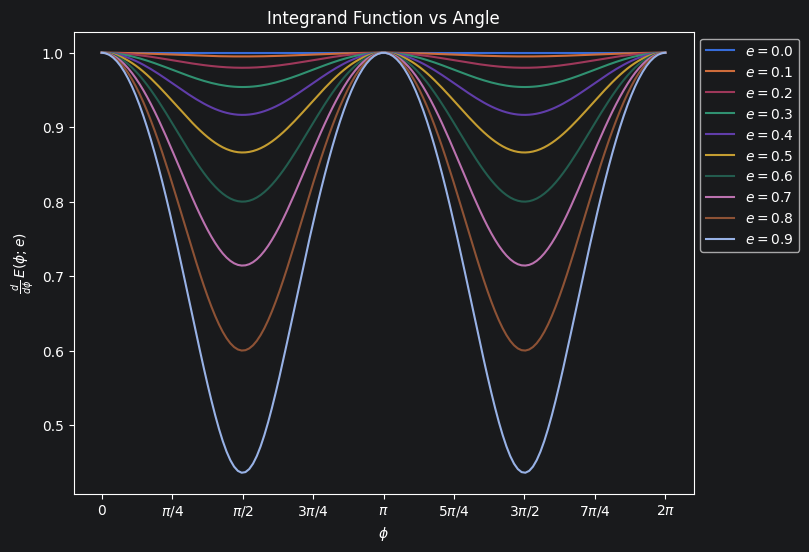

In [19]:
integrand_plot(2)

Let's compute the complete elliptic integral of the second kind in function of eccentricity $e$

In [20]:
complete_second_kind = ellipe(values_array ** 2)
complete_second_kind

array([1.57079633, 1.57077887, 1.57072651, 1.57063924, 1.57051704,
       1.5703599 , 1.57016782, 1.56994077, 1.56967872, 1.56938165,
       1.56904954, 1.56868234, 1.56828003, 1.56784255, 1.56736987,
       1.56686194, 1.56631871, 1.56574011, 1.5651261 , 1.56447661,
       1.56379156, 1.56307091, 1.56231455, 1.56152243, 1.56069445,
       1.55983054, 1.55893059, 1.55799452, 1.55702222, 1.5560136 ,
       1.55496855, 1.55388694, 1.55276868, 1.55161363, 1.55042168,
       1.54919268, 1.54792651, 1.54662303, 1.5452821 , 1.54390355,
       1.54248724, 1.54103301, 1.53954069, 1.53801011, 1.5364411 ,
       1.53483346, 1.53318703, 1.53150159, 1.52977695, 1.5280129 ,
       1.52620923, 1.52436573, 1.52248215, 1.52055828, 1.51859387,
       1.51658866, 1.51454242, 1.51245486, 1.51032573, 1.50815475,
       1.50594161, 1.50368604, 1.50138771, 1.49904633, 1.49666156,
       1.49423307, 1.49176051, 1.48924353, 1.48668177, 1.48407484,
       1.48142236, 1.47872393, 1.47597913, 1.47318754, 1.47034

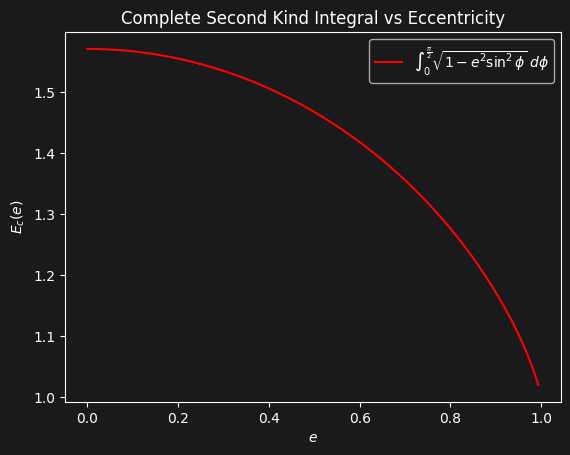

In [21]:
plot_kind(2)

In [22]:
grad = np.gradient(complete_second_kind)
grad

array([-1.74534380e-05, -3.49077487e-05, -6.98189888e-05, -1.04737214e-04,
       -1.39665921e-04, -1.74608614e-04, -2.09568802e-04, -2.44550008e-04,
       -2.79555763e-04, -3.14589613e-04, -3.49655120e-04, -3.84755865e-04,
       -4.19895446e-04, -4.55077485e-04, -4.90305627e-04, -5.25583545e-04,
       -5.60914937e-04, -5.96303536e-04, -6.31753105e-04, -6.67267442e-04,
       -7.02850384e-04, -7.38505808e-04, -7.74237633e-04, -8.10049822e-04,
       -8.45946387e-04, -8.81931391e-04, -9.18008949e-04, -9.54183232e-04,
       -9.90458470e-04, -1.02683895e-03, -1.06332904e-03, -1.09993316e-03,
       -1.13665580e-03, -1.17350155e-03, -1.21047504e-03, -1.24758101e-03,
       -1.28482428e-03, -1.32220976e-03, -1.35974245e-03, -1.39742745e-03,
       -1.43526997e-03, -1.47327532e-03, -1.51144892e-03, -1.54979632e-03,
       -1.58832319e-03, -1.62703530e-03, -1.66593860e-03, -1.70503915e-03,
       -1.74434316e-03, -1.78385700e-03, -1.82358720e-03, -1.86354044e-03,
       -1.90372361e-03, -

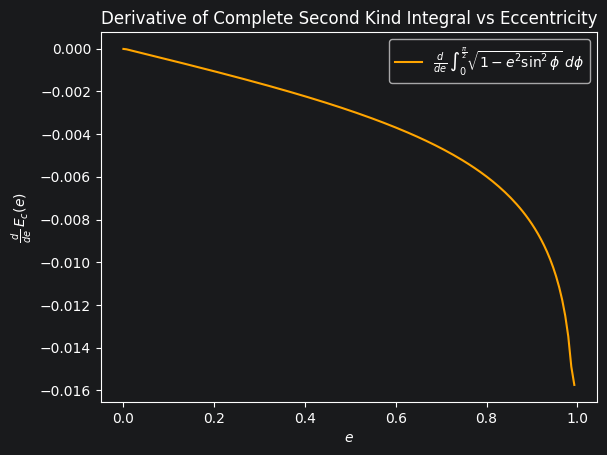

In [23]:
plot_grad(2)

Let's compute the incomplete elliptic integral of the second kind in function of $\phi$, for different values of eccentricity $e$

In [24]:
incomplete_second_kind = ellipeinc(phi_array[:, None], some_values[None, :] ** 2)
incomplete_second_kind

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04216903, 0.0421689 , 0.04216853, ..., 0.04216291, 0.04216103,
        0.04215891],
       [0.08433806, 0.08433706, 0.08433406, ..., 0.08428911, 0.08427412,
        0.08425712],
       ...,
       [6.19884725, 6.18311071, 6.13554012, ..., 5.33835543, 5.02112566,
        4.60253109],
       [6.24101628, 6.22527886, 6.17770566, ..., 5.38048164, 5.06323874,
        4.6446293 ],
       [6.28318531, 6.26744777, 6.21987418, ..., 5.42264454, 5.10539977,
        4.68678821]], shape=(150, 10))

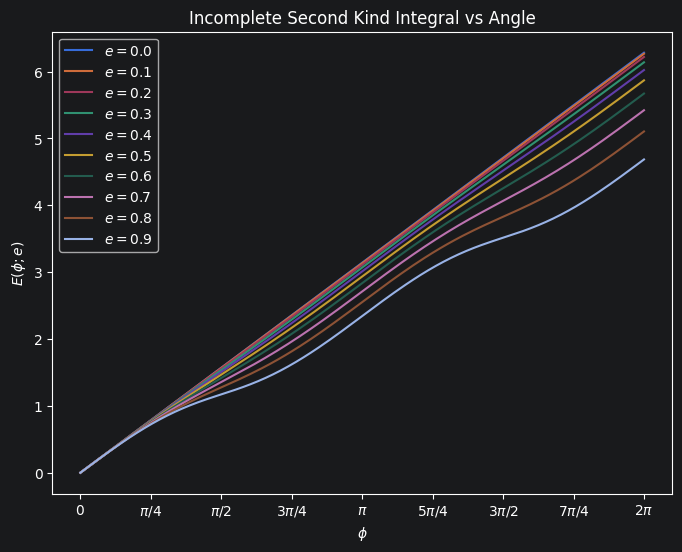

In [25]:
plot_phi(2)

In [26]:
grad = np.gradient(incomplete_second_kind, some_values, axis = 1)
grad

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.24932736e-06, -2.49867471e-06, -4.99742936e-06, ...,
        -1.74952017e-05, -1.99961168e-05, -2.12467245e-05],
       [-9.98404020e-06, -1.99687184e-05, -3.99399890e-05, ...,
        -1.39924204e-04, -1.59964633e-04, -1.69989666e-04],
       ...,
       [-1.57365407e-01, -3.16535642e-01, -6.40529602e-01, ...,
        -2.83452910e+00, -3.67912169e+00, -4.18594563e+00],
       [-1.57374142e-01, -3.16553112e-01, -6.40564545e-01, ...,
        -2.83465153e+00, -3.67926166e+00, -4.18609437e+00],
       [-1.57375391e-01, -3.16555611e-01, -6.40569542e-01, ...,
        -2.83466903e+00, -3.67928166e+00, -4.18611562e+00]],
      shape=(150, 10))

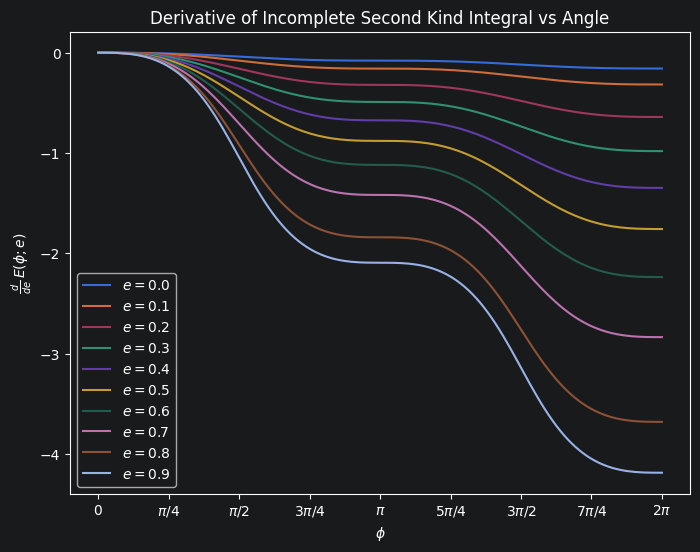

In [27]:
plot_grad_phi(2)

### Jacobi functions

Get back to incomplete elliptic integral of the first kind:

$$
    K(\phi;\, k) = \int_0^{\phi} \frac{d\phi'}{\sqrt{1 - k^2\sin^2\phi'}}
$$

The inverse function $\phi \rightarrow K$ is called "amplitude":

$$
    am(K; k) = \phi
$$

The basic three Jacobi functions are:

$$
    sn(K; k) = \sin(am(K; k)) = \sin{\phi}
$$

$$
    cn(K; k) = \cos(am(K; k)) = \cos{\phi}
$$

$$
    dn(K; k) = \sqrt{1 - k ^ 2 \, \sin^2{\phi}} = \sqrt{1 - k^2 \, sn^2(K; k)}
$$

Let's compute them

In [28]:
from scipy.special import ellipj # Jacobian functions

In [29]:
# Plot a Jacobi function
def plot_jacobi(jacobi):
    global some_values, incomplete_first_kind, phi_array

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6), sharey = True)

    ax1.set_title('Jacobi function vs K')
    ax1.set_xlabel(r'$K$')
    ax1.set_ylabel(r'$j(K; k)$')

    ax2.set_title('Jacobi function vs Angle')

    ax2.set_xlabel(r'$\phi$')
    positions = np.linspace(0, 2 * np.pi, 9)
    tick_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$', r'$5\pi/4$', r'$3\pi/2$', r'$7\pi/4$', r'$2\pi$']
    ax2.set_xticks(positions)
    ax2.set_xticklabels(tick_labels)

    for i, value in enumerate(some_values):
        ax1.plot(incomplete_first_kind[:, i], jacobi[:, i], label = fr'$k = {value:.1f}$')
        ax2.plot(phi_array, jacobi[:, i])

    ax1.legend(loc = 'best')

    plt.tight_layout()
    plt.show()

    return None

In [30]:
sn, cn, dn, am = ellipj(incomplete_first_kind, some_values ** 2)

In [31]:
sn

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.21565323e-02,  4.21565323e-02,  4.21565323e-02, ...,
         4.21565323e-02,  4.21565323e-02,  4.21565323e-02],
       [ 8.42381119e-02,  8.42381119e-02,  8.42381119e-02, ...,
         8.42381119e-02,  8.42381119e-02,  8.42381119e-02],
       ...,
       [-8.42381119e-02, -8.42381119e-02, -8.42381119e-02, ...,
        -8.42381119e-02, -8.42381119e-02, -8.42381119e-02],
       [-4.21565323e-02, -4.21565323e-02, -4.21565323e-02, ...,
        -4.21565323e-02, -4.21565323e-02, -4.21565323e-02],
       [-2.44921271e-16, -1.13309969e-15, -1.13309969e-15, ...,
        -2.44921271e-16, -1.13309969e-15,  6.43257149e-16]],
      shape=(150, 10))

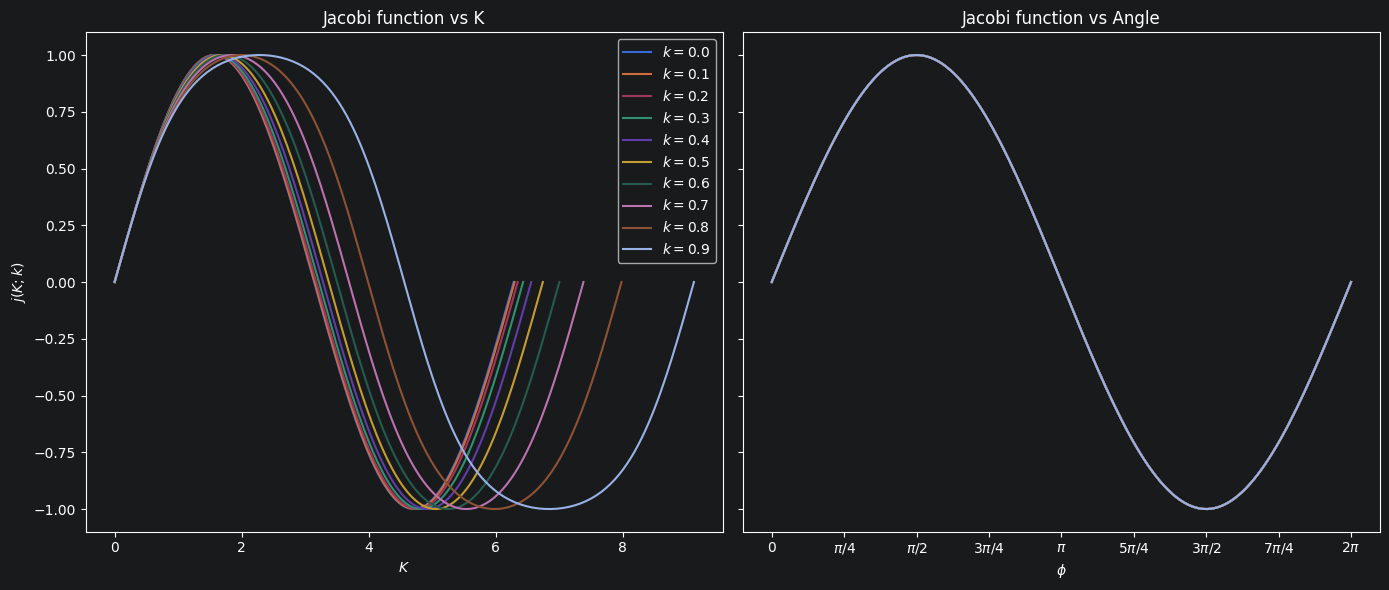

In [32]:
plot_jacobi(sn)

In [33]:
cn

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.99911102, 0.99911102, 0.99911102, ..., 0.99911102, 0.99911102,
        0.99911102],
       [0.99644565, 0.99644565, 0.99644565, ..., 0.99644565, 0.99644565,
        0.99644565],
       ...,
       [0.99644565, 0.99644565, 0.99644565, ..., 0.99644565, 0.99644565,
        0.99644565],
       [0.99911102, 0.99911102, 0.99911102, ..., 0.99911102, 0.99911102,
        0.99911102],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(150, 10))

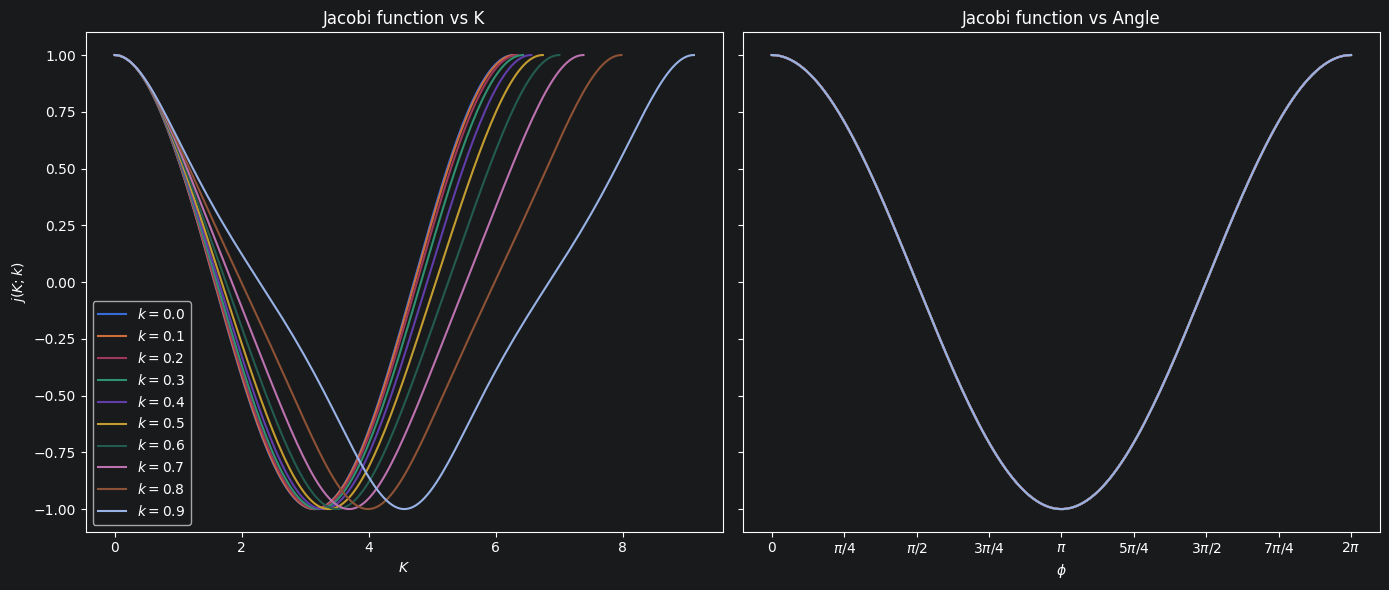

In [34]:
plot_jacobi(cn)

In [35]:
dn

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [1.        , 0.99999111, 0.99996446, ..., 0.9995645 , 0.99943114,
        0.99927999],
       [1.        , 0.99996452, 0.99985807, ..., 0.99825995, 0.99772668,
        0.99712195],
       ...,
       [1.        , 0.99996452, 0.99985807, ..., 0.99825995, 0.99772668,
        0.99712195],
       [1.        , 0.99999111, 0.99996446, ..., 0.9995645 , 0.99943114,
        0.99927999],
       [1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(150, 10))

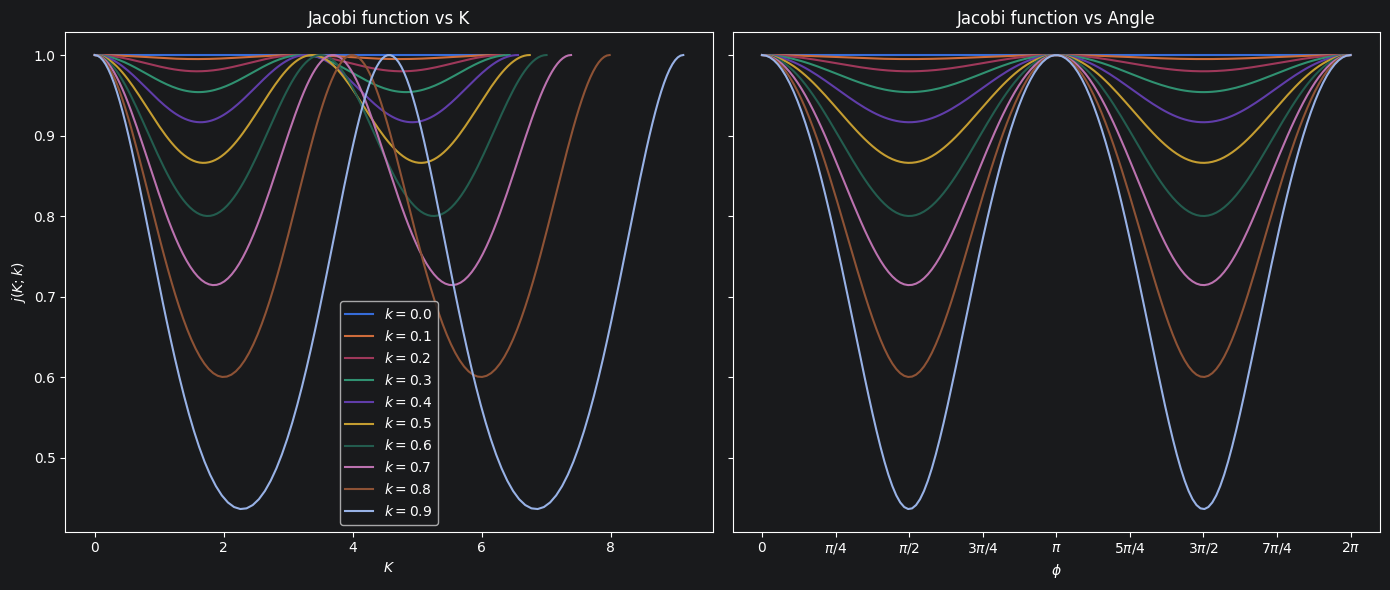

In [36]:
plot_jacobi(dn)

In [37]:
am

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.04216903, 0.04216903, 0.04216903, ..., 0.04216903, 0.04216903,
        0.04216903],
       [0.08433806, 0.08433806, 0.08433806, ..., 0.08433806, 0.08433806,
        0.08433806],
       ...,
       [6.19884725, 6.19884725, 6.19884725, ..., 6.19884725, 6.19884725,
        6.19884725],
       [6.24101628, 6.24101628, 6.24101628, ..., 6.24101628, 6.24101628,
        6.24101628],
       [6.28318531, 6.28318531, 6.28318531, ..., 6.28318531, 6.28318531,
        6.28318531]], shape=(150, 10))

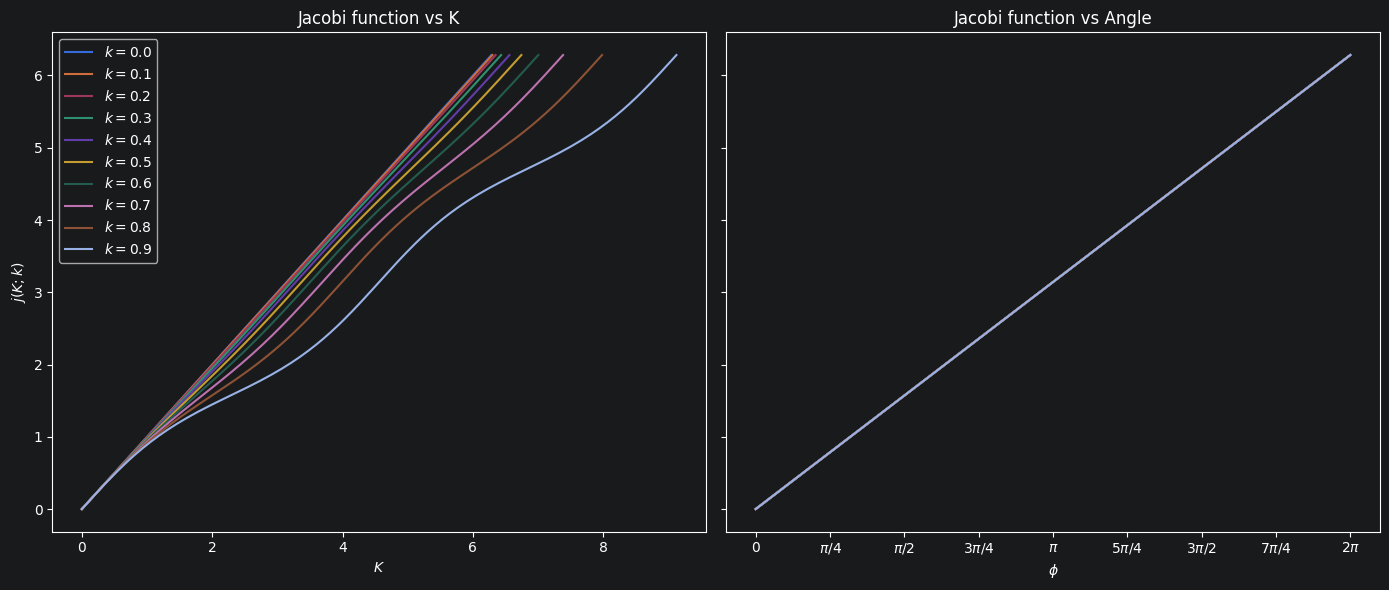

In [38]:
plot_jacobi(am)